# CSE 4836 - Pattern Recognition Lab 4

# Introduction

In this lab, you will study convolutional neural networks (CNNs). You will begin by implementing a two-dimensional convolution operation, apply hand-designed filters to an image, and compare your implementation with PyTorch. You will then construct a CNN whose filters can be assigned by hand, train a CNN on CIFAR-10, visualize its internal feature maps, and use ImageNet-pretrained ResNet-50 for transfer learning.

The notebook is organized so that each section first introduces the required components, demonstrates them in an example, and then provides tasks for you to extend and interpret the results.

# Import External Libraries

In [ ]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms

EPS = 1e-8
SEED = 117
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# File Paths

In [ ]:
import os

In [ ]:
LAB4_DIR = "/content"
DATA_DIR = LAB4_DIR + "/datasets"
PLUS_MINUS_DIR = DATA_DIR + "/PlusMinus"

SPIDER_CITY_PATH = DATA_DIR + "/spider-city.jpg"
LION_PATH = DATA_DIR + "/lion.jpg"
FULL_BLACK_PATH = DATA_DIR + "/fullBlack.png"
FULL_WHITE_PATH = DATA_DIR + "/fullWhite.png"

In [ ]:
if not os.path.exists(DATA_DIR):
    !gdown 1oS4xICvoAv1CUIVGX0erwVtCxM0wpo3o

Downloading...
From: https://drive.google.com/uc?id=1oS4xICvoAv1CUIVGX0erwVtCxM0wpo3o
To: /content/lab4.zip
100% 101k/101k [00:00<00:00, 137MB/s]


In [ ]:
if not os.path.exists(DATA_DIR):
    !unzip lab4.zip

Archive:  lab4.zip
   creating: datasets/
  inflating: datasets/spider-city.jpg  
  inflating: datasets/script.py      
  inflating: datasets/lion.jpg       
  inflating: datasets/fullBlack.png  
   creating: datasets/PlusMinus/
  inflating: datasets/PlusMinus/img19.png  
  inflating: datasets/PlusMinus/img31.png  
  inflating: datasets/PlusMinus/img96.png  
  inflating: datasets/PlusMinus/img97.png  
  inflating: datasets/PlusMinus/img28.png  
  inflating: datasets/PlusMinus/img72.png  
  inflating: datasets/PlusMinus/img09.png  
  inflating: datasets/PlusMinus/img40.png  
  inflating: datasets/PlusMinus/img49.png  
  inflating: datasets/PlusMinus/img55.png  
  inflating: datasets/PlusMinus/img35.png  
  inflating: datasets/PlusMinus/img92.png  
  inflating: datasets/PlusMinus/img95.png  
  inflating: datasets/PlusMinus/img42.png  
  inflating: datasets/PlusMinus/img98.png  
  inflating: datasets/PlusMinus/img02.png  
  inflating: datasets/PlusMinus/img11.png  
  inflating: datasets/P

# Convolution

A convolution filter moves across an image. At each location, it multiplies the values in a local image patch by the corresponding kernel values and sums the products. The resulting number becomes one pixel in the output feature map.

In this lab, `padding` adds a border of zeros around the image and `stride` controls how far the kernel moves after each calculation. The function below operates on a single-channel image and a single-channel kernel.

In [ ]:
def convolve(image, kernel, padding=0, stride=1):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError("image and kernel must both be two-dimensional")

    if padding > 0:
        image = np.pad(
            image,
            ((padding, padding), (padding, padding)),
            mode="constant",
            constant_values=0,
        )

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1
    output = np.zeros((output_height, output_width))

    for row in range(output_height):
        for col in range(output_width):
            row_start = row * stride
            col_start = col * stride
            patch = image[
                row_start : row_start + kernel_height,
                col_start : col_start + kernel_width,
            ]
            output[row, col] = np.sum(patch * kernel)

    return output

# Example 1

## Load Image

Image shape: (450, 800)
Pixel range: 0 to 241


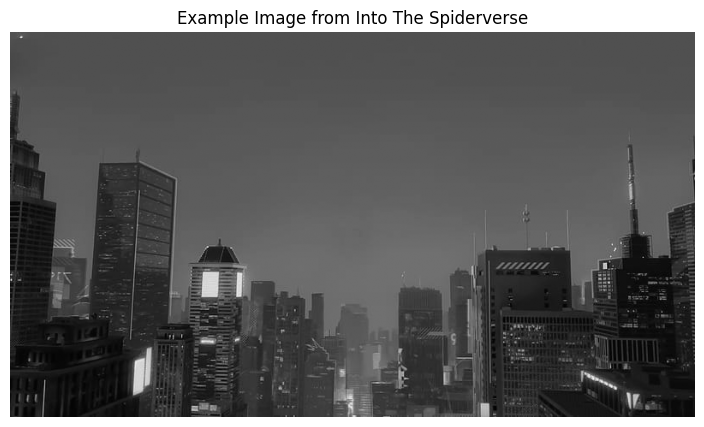

In [ ]:
spider_city = Image.open(SPIDER_CITY_PATH).convert("L")
spider_city_array = np.array(spider_city)

print(f"Image shape: {spider_city_array.shape}")
print(f"Pixel range: {spider_city_array.min()} to {spider_city_array.max()}")

plt.figure(figsize=(12, 5))
plt.imshow(spider_city_array, cmap="gray")
plt.title("Example Image from Into The Spiderverse")
plt.axis("off")
plt.show()

## Prepare Filters

In [ ]:
vertical_edge_filter = np.array([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
])

horizontal_edge_filter = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

vertical_edge_map = convolve(spider_city_array, vertical_edge_filter)
horizontal_edge_map = convolve(spider_city_array, horizontal_edge_filter)

print("Vertical-edge output map:")
print(vertical_edge_map)
print("Horizontal-edge output map:")
print(horizontal_edge_map)

Vertical-edge output map:
[[ 0.  3.  3. ...  0.  0.  0.]
 [ 0.  3.  3. ...  0.  0.  0.]
 [ 0.  3.  3. ...  0.  0.  0.]
 ...
 [36. 34.  2. ...  9. 12. 15.]
 [37. 34.  1. ...  7. 11. 14.]
 [35. 36. 11. ...  5. 10. 13.]]
Horizontal-edge output map:
[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [-4. -4. -4. ...  0.  0.  0.]
 [-5. -5. -5. ... -3. -5. -7.]
 [-9. -9.  1. ... -3. -5. -7.]]


## Visualize Output Maps

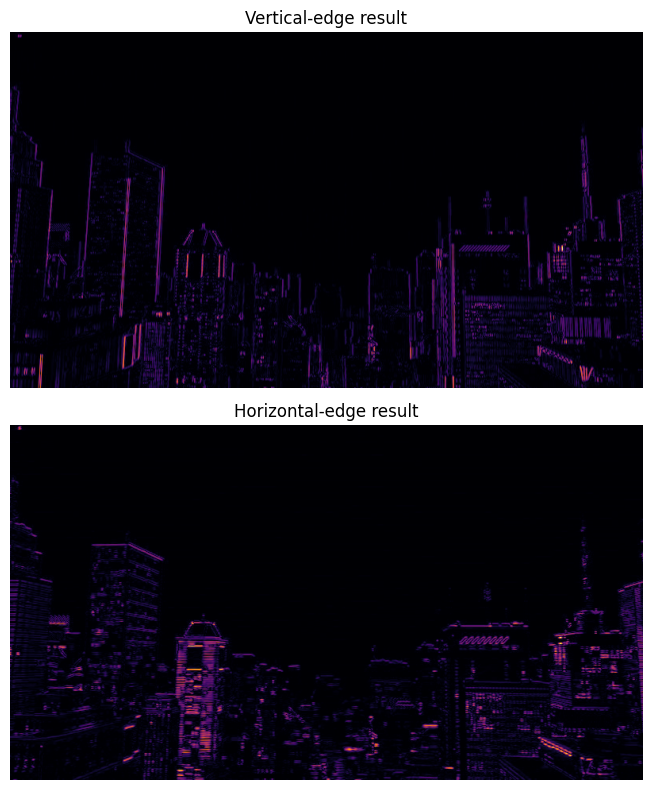

In [ ]:
figure, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].imshow(np.abs(vertical_edge_map), cmap="inferno")
axes[0].set_title("Vertical-edge result")
axes[0].axis("off")

axes[1].imshow(np.abs(horizontal_edge_map), cmap="inferno")
axes[1].set_title("Horizontal-edge result")
axes[1].axis("off")

plt.tight_layout()
plt.show()

The values in an output map may be positive or negative. A heatmap makes the spatial pattern easier to see, but it also applies a color mapping to the values. Therefore, the array and the heatmap provide complementary information.

## PyTorch `conv2d`

PyTorch expects convolution inputs in the form `(batch, channels, height, width)` and filters in the form `(output_channels, input_channels, height, width)`. Although it is called convolution, PyTorch uses cross-correlation internally: it does not flip the kernel before applying it.

The filters below are the same filters used in the manual implementation.

In [ ]:
def torch_convolve(image, kernel, padding=0, stride=1):
    image_tensor = torch.tensor(image, dtype=torch.float32)[None, None]
    kernel_tensor = torch.tensor(kernel, dtype=torch.float32)[None, None]
    return F.conv2d(
        image_tensor,
        kernel_tensor,
        padding=padding,
        stride=stride,
    )[0, 0].numpy()

vertical_edge_map_torch = torch_convolve(spider_city_array, vertical_edge_filter)
horizontal_edge_map_torch = torch_convolve(spider_city_array, horizontal_edge_filter)

print("Maximum vertical-map difference:", np.max(np.abs(vertical_edge_map - vertical_edge_map_torch)))
print("Maximum horizontal-map difference:", np.max(np.abs(horizontal_edge_map - horizontal_edge_map_torch)))

Maximum vertical-map difference: 0.0
Maximum horizontal-map difference: 0.0


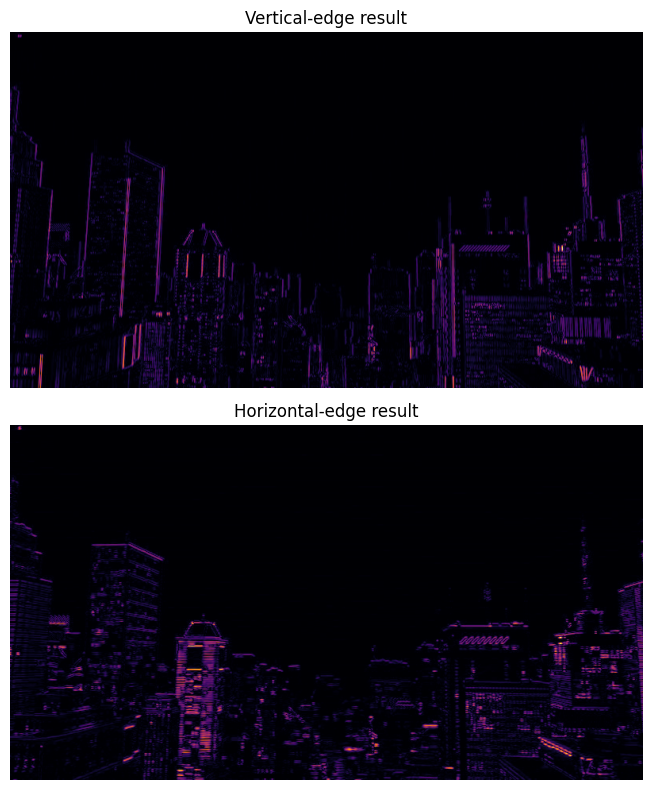

In [ ]:
figure, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].imshow(np.abs(vertical_edge_map_torch), cmap="inferno")
axes[0].set_title("Vertical-edge result")
axes[0].axis("off")

axes[1].imshow(np.abs(horizontal_edge_map_torch), cmap="inferno")
axes[1].set_title("Horizontal-edge result")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Task 1

Design a filter of your own. Before running the code, explain what visual pattern you expect the filter to emphasize. Then apply it to `spider-city.jpg` and compare the result with your prediction.

In [ ]:
left_edge_filter = np.array([
    [0,  0,  1,  0,  0],
    [0,  0,  1,  0,  0],
    [0,  0,  1,  0,  0],
    [0,  0,  1,  0,  0],
    [0,  0,  1,  0,  0]
])

right_edge_filter = np.array([
    [0,  0,  1,  0,  0],
    [0,  1,  0,  1,  0],
    [1,  0,  0,  0,  1],
    [0,  1,  0,  1,  0],
    [0,  0,  1,  0,  0]
])


Here, as the both filters are diagonal matrix, so we would have the diagonal responses. We might also get some weak responsed of vertical and horizontal also

In [ ]:
custom_result = torch_convolve(spider_city_array, custom_filter)
print(custom_result)

[[387. 388. 390. ... 380. 380. 380.]
 [387. 388. 390. ... 380. 380. 380.]
 [387. 388. 390. ... 380. 380. 380.]
 ...
 [191. 181. 152. ...  51.  56.  64.]
 [189. 188. 161. ...  49.  53.  60.]
 [193. 209. 203. ...  47.  51.  57.]]


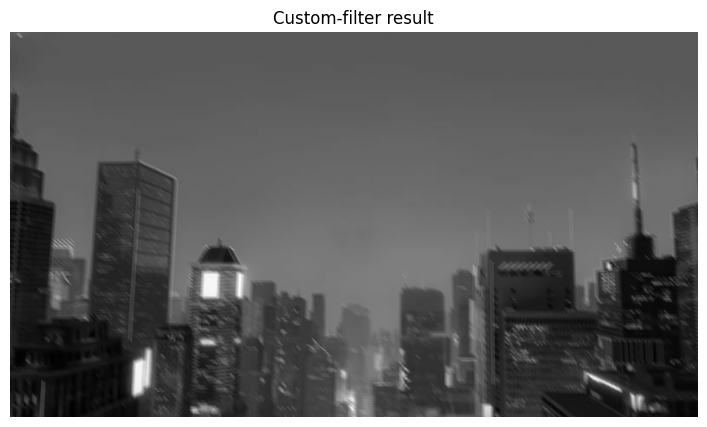

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(custom_result, cmap="gray")
plt.title("Custom-filter result")
plt.axis("off")
plt.show()

In [ ]:
left_edge_map = convolve(spider_city_array, left_edge_filter)
right_edge_map = convolve(spider_city_array, right_edge_filter)

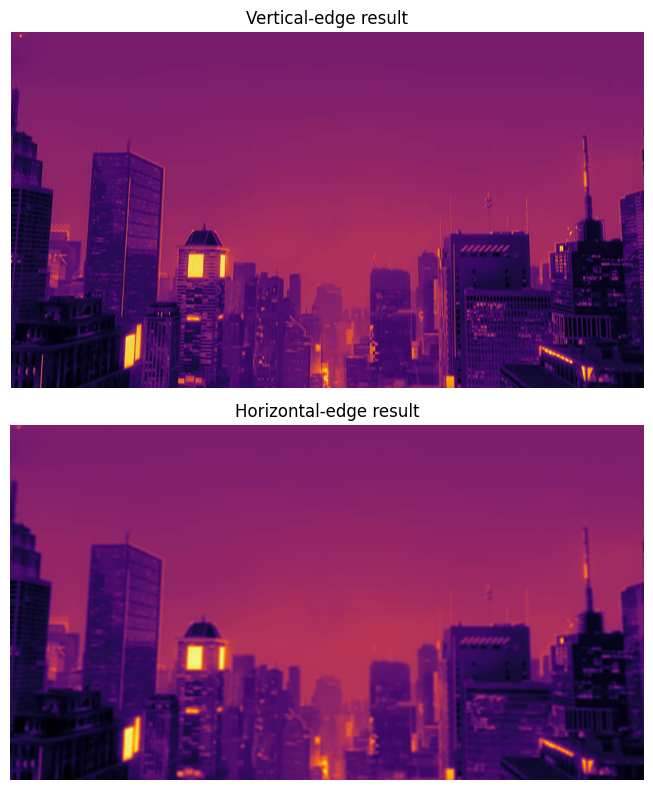

In [ ]:
figure, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].imshow(np.abs(left_edge_map), cmap="inferno")
axes[0].set_title("Vertical-edge result")
axes[0].axis("off")

axes[1].imshow(np.abs(right_edge_map), cmap="inferno")
axes[1].set_title("Horizontal-edge result")
axes[1].axis("off")

plt.tight_layout()
plt.show()

YOUR REPORT HERE

# Dataset Classes

## `PlusMinusDataset`

`PlusMinusDataset` reads the filename-to-class mapping from `labels.csv` and loads the corresponding PNG image when a sample is requested. The class follows the PyTorch `Dataset` interface, so it can be passed directly to a `DataLoader`.

Class ID `0` represents a minus and class ID `1` represents a plus. Images are returned as tensors with shape `(1, 15, 15)` and values in the range `0` to `255`.

In [ ]:
class PlusMinusDataset(Dataset):
    def __init__(self, dataset_dir):
        self.dataset_dir = Path(dataset_dir)
        labels_path = self.dataset_dir / "labels.csv"

        self.samples = []
        with labels_path.open("r", newline="") as file:
            reader = csv.DictReader(file)
            for row in reader:
                self.samples.append((row["filename"], int(row["class_id"])))

        self.class_names = ["minus", "plus"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, class_id = self.samples[idx]
        image = Image.open(self.dataset_dir / filename).convert("L")
        image = torch.tensor(np.array(image), dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(class_id, dtype=torch.long)
        return image, label

plus_minus_dataset = PlusMinusDataset(PLUS_MINUS_DIR)
print("Number of samples:", len(plus_minus_dataset))
print("First sample:", plus_minus_dataset[0][0].shape, plus_minus_dataset[0][1].item())

Number of samples: 100
First sample: torch.Size([1, 15, 15]) 1


## DataLoader

In [ ]:
plus_minus_loader = DataLoader(
    plus_minus_dataset,
    batch_size=16,
    shuffle=True,
)

print("Number of batches:", len(plus_minus_loader))

Number of batches: 7


## Visualize Dataset

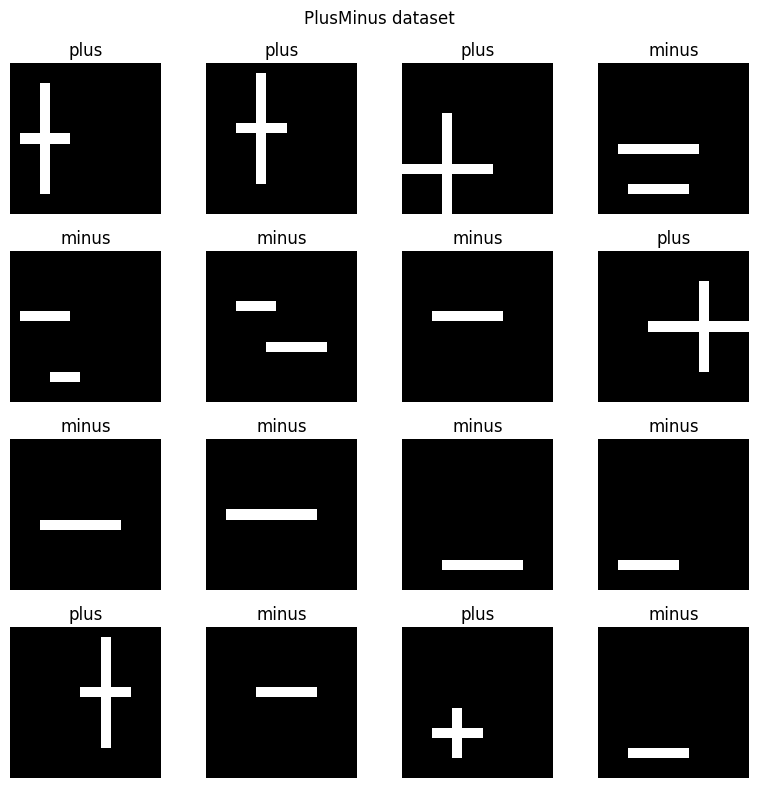

In [ ]:
def show_plus_minus_samples(dataset, n=16):
    figure, axes = plt.subplots(4, 4, figsize=(8, 8))

    for axis, idx in zip(axes.flat, range(min(n, len(dataset)))):
        image, label = dataset[idx]
        axis.imshow(image[0], cmap="gray", vmin=0, vmax=255)
        axis.set_title(dataset.class_names[label.item()])
        axis.axis("off")

    figure.suptitle("PlusMinus dataset")
    plt.tight_layout()
    plt.show()

show_plus_minus_samples(plus_minus_dataset)

# Example 2

## Two-Layer CNN

The first layer has one 3×3 filter. Its positive weights are placed on the central row and central column, while the corner weights are negative. With the chosen bias, the response is positive at the center of a plus and non-positive for a horizontal minus.

The first layer produces a 13×13 feature map. The second layer uses two 13×13 filters, so each filter reduces that feature map to one score. The first output score corresponds to minus and the second corresponds to plus.

In [ ]:
class HandDesignedPlusMinusCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolution_1 = nn.Conv2d(1, 1, kernel_size=3, bias=True)
        self.convolution_2 = nn.Conv2d(1, 2, kernel_size=13, bias=True)

        with torch.no_grad():
            first_filter = torch.tensor([
                [-5, 4, -5],
                [4, 4, 4],
                [-5, 4, -5],
            ], dtype=torch.float32)
            self.convolution_1.weight.copy_(first_filter.reshape(1, 1, 3, 3))
            self.convolution_1.bias.fill_(-5099)

            self.convolution_2.weight[0].fill_(-1)
            self.convolution_2.weight[1].fill_(1)
            self.convolution_2.bias[0] = 0
            self.convolution_2.bias[1] = -1

    def forward(self, x):
        x = F.relu(self.convolution_1(x))
        return self.convolution_2(x).flatten(1)

hand_designed_model = HandDesignedPlusMinusCNN().to(device)
print(hand_designed_model)

HandDesignedPlusMinusCNN(
  (convolution_1): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
  (convolution_2): Conv2d(1, 2, kernel_size=(13, 13), stride=(1, 1))
)


## Analyzer Classes

In [ ]:
class ModelPerformanceAnalyzer:
    def test(self, model, testset):
        y_true = []
        y_pred = []

        model.eval()
        with torch.no_grad():
            for x, y in testset:
                scores = model(x.to(device).unsqueeze(0))
                y_hat = torch.argmax(scores, dim=1).item()
                y_true.append(y.item())
                y_pred.append(y_hat)

        return self.compute(np.array(y_true), np.array(y_pred))

    def compute(self, y_true, y_pred):
        raise NotImplementedError


class AccuracyAnalyzer(ModelPerformanceAnalyzer):
    def compute(self, y_true, y_pred):
        return np.mean(y_true == y_pred)


class ConfusionMatrixAnalyzer(ModelPerformanceAnalyzer):
    def compute(self, y_true, y_pred):
        matrix = np.zeros((2, 2), dtype=int)
        for true_class, predicted_class in zip(y_true, y_pred):
            matrix[true_class, predicted_class] += 1
        return matrix

## Analyze Results

In [ ]:
accuracy_analyzer = AccuracyAnalyzer()
confusion_analyzer = ConfusionMatrixAnalyzer()

In [ ]:
accuracy = accuracy_analyzer.test(hand_designed_model, plus_minus_dataset)
confusion_matrix_result = confusion_analyzer.test(hand_designed_model, plus_minus_dataset)

print(f"Accuracy: {accuracy * 100:.1f}%")
print(confusion_matrix_result)

Accuracy: 100.0%
[[50  0]
 [ 0 50]]


The model is not trained. Its parameters were chosen from the geometry of the images and assigned directly before evaluation. A 100% result demonstrates that a CNN can express a useful decision rule, but it does not mean that the same rule will work on a more varied dataset.

# Task 2

## Full Black and Full White Images

Predict the output class for `fullBlack.png` and `fullWhite.png`. Explain your prediction and then run the following cell to verify.

##Prediction
---

My prediction is for both the image it will predict minus. As, our filter is of plus shape , as in whole image it can't find any similar plus shape so it will predict minus always, in both dark and white image

In [ ]:
def predict_image(model, image_path):
    image = Image.open(image_path).convert("L")
    image_tensor = torch.tensor(np.array(image), dtype=torch.float32)[None, None]

    with torch.no_grad():
        scores = model(image_tensor.to(device))[0]

    return scores.cpu().numpy(), int(scores.argmax().item())

test_image_paths = {
    "Black": FULL_BLACK_PATH,
    "White": FULL_WHITE_PATH
}

for race, image_path in test_image_paths.items():
    scores, prediction = predict_image(hand_designed_model, image_path)
    print("Image:", race, "Scores:", scores, "Prediction:", plus_minus_dataset.class_names[prediction])

Image: Black Scores: [ 0. -1.] Prediction: minus
Image: White Scores: [ 0. -1.] Prediction: minus


YOUR REPORT HERE

# Task 3

Design a different two-layer CNN and manually assign its filters so that it classifies every PlusMinus image correctly without training. You may change the first-layer filter, the second-layer filters, the biases, or the way the scores are aggregated. Justify your design and report the accuracy and confusion matrix.

In [ ]:
class HandDesignedPlusMinusCNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.convolution_1 = nn.Conv2d(1, 1, kernel_size=3, bias=True)
        self.convolution_2 = nn.Conv2d(1, 2, kernel_size=13, bias=True)

        with torch.no_grad():
            first_filter = torch.tensor([
                [-5, 4, -5],
                [-5, 4, -5],
                [-5, 4, -5],
            ], dtype=torch.float32)
            self.convolution_1.weight.copy_(first_filter.reshape(1, 1, 3, 3))
            self.convolution_1.bias.fill_(-2039)

            self.convolution_2.weight[0].fill_(-1)
            self.convolution_2.weight[1].fill_(1)
            self.convolution_2.bias[0] = 0
            self.convolution_2.bias[1] = -1

    def forward(self, x):
        x = F.relu(self.convolution_1(x))
        return self.convolution_2(x).flatten(1)

hand_designed_model2 = HandDesignedPlusMinusCNN2().to(device)
print(hand_designed_model)

HandDesignedPlusMinusCNN2(
  (convolution_1): Conv2d(1, 2, kernel_size=(3, 3), stride=(1, 1))
  (convolution_2): Conv2d(2, 2, kernel_size=(13, 13), stride=(1, 1))
)


In [ ]:
accuracy_analyzer = AccuracyAnalyzer()
confusion_analyzer = ConfusionMatrixAnalyzer()

accuracy = accuracy_analyzer.test(hand_designed_model2, plus_minus_dataset)
confusion_matrix_result = confusion_analyzer.test(hand_designed_model2, plus_minus_dataset)

print(f"Accuracy: {accuracy * 100:.1f}%")
print(confusion_matrix_result)

Accuracy: 100.0%
[[50  0]
 [ 0 50]]


## Hand-Designed CNN 2
---
- The first-layer filter was redesigned to detect **only vertical lines**, since the **'+'** symbol contains a vertical stroke while the **'−'** symbol does not. Thus, the presence of a vertical activation predicts **'+'**, and its absence predicts **'−'**. The second layer remained unchanged.

- The filter's maximum response is **3060** for a perfect vertical line (3 × 4 × 255). The bias acts as a threshold before ReLU. An optimal bias of **-2039** preserved all valid vertical activations while suppressing non-vertical responses, resulting in **100% accuracy**. Increasing the threshold (bias ≤ -2040) suppressed some valid activations, reducing the accuracy to about **86%**, and eventually to **50%** when all activations became zero.

- The optimal bias **-2039** is choosed after several trial and error. This value gives 100% accuracy. It is because, the plus sign's vertical line is not equal or same in all the images, it varies in thickness, length or height etc. So , instead of maximum response **-3060** we need to take the value **-2039**.



# Data Augmentation

The PlusMinus problem is deliberately simple: the objects are binary, small, and aligned with the image axes. Real images contain changes in position, scale, lighting, color, background, and viewpoint. Data augmentation creates additional training examples by applying transformations that should preserve the class.

In [ ]:
lion = Image.open(LION_PATH).convert("RGB")

from torchvision import transforms

lion_transformations = {
    "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
    "Vertical Flip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation 25°": transforms.RandomRotation(degrees=25),
    "Rotation 90°": transforms.RandomRotation(degrees=(90, 90)),
    "Translation": transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    "Scaling": transforms.RandomAffine(degrees=0, scale=(0.7, 1.3)),
    "Shear": transforms.RandomAffine(degrees=0, shear=20),
    "Color Jitter": transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5,
        hue=0.1
    ),
    "Random Crop": transforms.RandomResizedCrop(
        size=lion.size,
        scale=(0.65, 1.0)
    ),
    "Perspective": transforms.RandomPerspective(
        distortion_scale=0.5,
        p=1.0
    ),
    "Gaussian Blur": transforms.GaussianBlur(
        kernel_size=5,
        sigma=(0.1, 2.0)
    ),
    "Sharpness": transforms.RandomAdjustSharpness(
        sharpness_factor=2,
        p=1.0
    ),
}

figure, axes = plt.subplots(4, 3, figsize=(15, 18))
axes[0, 0].imshow(lion)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for axis, (name, transformation) in zip(axes.flat[1:], lion_transformations.items()):
    axis.imshow(transformation(lion))
    axis.set_title(name)
    axis.axis("off")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

# CIFAR-10 Dataset

CIFAR-10 contains 60,000 color images from 10 classes. The images are 32×32 pixels, which makes this dataset suitable for a small CNN. The training set uses augmentation, while the test set uses only deterministic preprocessing.

The two datasets intentionally use different transforms: random changes are appropriate during training, but test accuracy should be measured on an unchanged and consistently processed test set.

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

cifar10_trainset = datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=train_transform
)
cifar10_testset = datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=test_transform
)

cifar10_trainloader = DataLoader(
    cifar10_trainset, batch_size=128, shuffle=True, num_workers=2
)
cifar10_testloader = DataLoader(
    cifar10_testset, batch_size=256, shuffle=False, num_workers=2
)

print("Training samples:", len(cifar10_trainset))
print("Test samples:", len(cifar10_testset))

In [ ]:
CIFAR10_CLASS_NAMES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

def denormalize_cifar10(image):
    mean = torch.tensor(CIFAR10_MEAN)[:, None, None]
    std = torch.tensor(CIFAR10_STD)[:, None, None]
    return (image * std + mean).clamp(0, 1)

def show_cifar10_samples(dataset, title, n=16):
    figure, axes = plt.subplots(4, 4, figsize=(8, 8))
    for axis, idx in zip(axes.flat, range(n)):
        image, label = dataset[idx]
        axis.imshow(denormalize_cifar10(image).permute(1, 2, 0))
        axis.set_title(CIFAR10_CLASS_NAMES[label])
        axis.axis("off")
    figure.suptitle(title)
    plt.tight_layout()
    plt.show()

show_cifar10_samples(cifar10_trainset, "CIFAR-10 training set with augmentation")
show_cifar10_samples(cifar10_testset, "CIFAR-10 test set without augmentation")

# Example 3

## Custom CNN

This network uses convolution and pooling layers to extract spatial features. The final fully connected layers convert the extracted feature representation into ten class scores. Unlike the hand-designed PlusMinus network, the parameters of this model will be learned from CIFAR-10.

In [ ]:
class ConvolutionalNeuralNetwork(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.convolution_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.fully_connected_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.convolution_layers(x)
        return self.fully_connected_layers(x)

cifar10_model = ConvolutionalNeuralNetwork(len(CIFAR10_CLASS_NAMES)).to(device)
print(cifar10_model)

## Training Function

In [ ]:
def accuracy(model, dataset_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in dataset_loader:
            scores = model(x.to(device))
            y_hat = torch.argmax(scores, dim=1).cpu()
            correct += torch.sum(y_hat == y).item()
            total += len(y)

    return correct / total


def train_cnn(model, train_loader, test_loader, num_epochs, learning_rate):
    loss_calculator = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"loss": [], "accuracy": []}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            loss = loss_calculator(scores, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        test_accuracy = accuracy(model, test_loader)
        history["loss"].append(epoch_loss)
        history["accuracy"].append(test_accuracy)

        print(
            f"Epoch {epoch + 1}/{num_epochs}: "
            f"loss={epoch_loss:.4f}, test accuracy={test_accuracy:.4f}"
        )

    return history

## Train Model

In [ ]:
cifar10_history = train_cnn(
    model=cifar10_model,
    train_loader=cifar10_trainloader,
    test_loader=cifar10_testloader,
    num_epochs=10,
    learning_rate=0.001,
)

## Analyze Results

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cifar10_history["loss"], marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")

axes[1].plot(cifar10_history["accuracy"], marker="o")
axes[1].set_title("Test accuracy")
axes[1].set_xlabel("epoch")

plt.tight_layout()
plt.show()

print(f"Final accuracy: {cifar10_history['accuracy'][-1] * 100:.2f}%")

## Visualize Intermediate Features

In [ ]:
def collect_convolution_outputs(model, image):
    outputs = {}
    hooks = []

    for layer_id, layer in enumerate(model.convolution_layers):
        if isinstance(layer, nn.Conv2d):
            hooks.append(
                layer.register_forward_hook(
                    lambda module, inputs, output, layer_id=layer_id: outputs.update(
                        {layer_id: output.detach().cpu()}
                    )
                )
            )

    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))

    for hook in hooks:
        hook.remove()

    return outputs


def visualize_feature_maps(model, dataset, sample_id=0, n_maps=8):
    image, label = dataset[sample_id]
    outputs = collect_convolution_outputs(model, image)

    figure, axes = plt.subplots(len(outputs), n_maps, figsize=(16, 3 * len(outputs)))
    if len(outputs) == 1:
        axes = np.array([axes])

    for row, (layer_id, output) in enumerate(outputs.items()):
        for col in range(n_maps):
            axes[row, col].imshow(output[0, col], cmap="viridis")
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(f"layer {layer_id}")

    figure.suptitle(f"Feature maps for {CIFAR10_CLASS_NAMES[label]}")
    plt.tight_layout()
    plt.show()

visualize_feature_maps(cifar10_model, cifar10_testset)

The first convolutional layers usually respond to local color and edge patterns. Later layers combine those responses over larger receptive fields. Later feature maps may show class-related structure, but they are not expected to look like recognizable photographs or simple drawings.

# ImageNet and Transfer Learning

ImageNet is a large image dataset with 1,000 object categories. A model trained on ImageNet learns reusable visual features such as edges, textures, shapes, and object parts. Transfer learning reuses those features for a new task.

In the next examples, ResNet-50 is first created with random weights and then created with weights learned from ImageNet.

# Example 4

## ResNet-50

In [ ]:
def prepare_imagenet_image(image_path, image_transform):
    image = Image.open(image_path).convert("RGB")
    tensor = image_transform(image).unsqueeze(0).to(device)
    return image, tensor

In [ ]:
imagenet_weights = models.ResNet50_Weights.DEFAULT
imagenet_transform = imagenet_weights.transforms()
class_names = imagenet_weights.meta["categories"]

lion_image, lion_tensor = prepare_imagenet_image(
    LION_PATH,
    imagenet_transform
)

In [ ]:
random_resnet50 = models.resnet50(weights=None).to(device)
random_resnet50.eval()

with torch.no_grad():
    random_scores = random_resnet50(lion_tensor)

random_probabilities = torch.softmax(random_scores[0], dim=0)
random_top_probabilities, random_top_ids = torch.topk(
    random_probabilities,
    k=5
)

print("Randomly Initialized ResNet-50")

for probability, class_id in zip(
    random_top_probabilities,
    random_top_ids
):
    print(
        f"{class_names[class_id]}: "
        f"{probability.item() * 100:.2f}%"
    )

A randomly initialized network has no reason to associate the lion image with the lion class. Its output is a demonstration of untrained model behavior, not a meaningful prediction.

In [ ]:
pretrained_resnet50 = models.resnet50(
    weights=imagenet_weights
).to(device)

pretrained_resnet50.eval()

with torch.no_grad():
    pretrained_scores = pretrained_resnet50(lion_tensor)

pretrained_probabilities = torch.softmax(
    pretrained_scores[0],
    dim=0
)

pretrained_top_probabilities, pretrained_top_ids = torch.topk(
    pretrained_probabilities,
    k=5
)

print("\nImageNet Pretrained ResNet-50")

for probability, class_id in zip(
    pretrained_top_probabilities,
    pretrained_top_ids
):
    print(
        f"{class_names[class_id]}: "
        f"{probability.item() * 100:.2f}%"
    )

The pretrained network can recognize visual categories because its parameters were learned from ImageNet. The exact top-1 result depends on the image and the pretrained weights, but a suitable lion image should produce a lion-related prediction among the strongest results.

# Task 4

## Fine-Tuning ResNet-50 on CIFAR-10

Replace the 1,000-class ImageNet classifier with a ten-class CIFAR-10 classifier. Compare these two settings:

1. Train only the new final layer while freezing the convolutional backbone.
2. Fine-tune every layer of the network.

Use the same training and test transforms for both settings. Explain how the number of trainable parameters, learning rate, training time, and final accuracy differ.

In [ ]:
CIFAR10_RESNET_MEAN = (0.485, 0.456, 0.406)
CIFAR10_RESNET_STD = (0.229, 0.224, 0.225)

resnet_train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_RESNET_MEAN, CIFAR10_RESNET_STD),
])

resnet_test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_RESNET_MEAN, CIFAR10_RESNET_STD),
])

resnet_trainset = datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=resnet_train_transform
)
resnet_testset = datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=resnet_test_transform
)

resnet_trainloader = DataLoader(resnet_trainset, batch_size=64, shuffle=True, num_workers=2)
resnet_testloader = DataLoader(resnet_testset, batch_size=128, shuffle=False, num_workers=2)

In [ ]:
def create_cifar10_resnet50(train_last_layer_only):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 10)

    if train_last_layer_only:
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True

    return model.to(device)


def train_resnet(model, train_loader, test_loader, num_epochs, learning_rate):
    loss_calculator = nn.CrossEntropyLoss()
    trainable_parameters = [
        parameter for parameter in model.parameters() if parameter.requires_grad
    ]
    optimizer = torch.optim.Adam(trainable_parameters, lr=learning_rate)
    history = {"loss": [], "accuracy": []}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            loss = loss_calculator(model(x), y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)
        test_accuracy = accuracy(model, test_loader)
        history["loss"].append(epoch_loss)
        history["accuracy"].append(test_accuracy)

        print(
            f"Epoch {epoch + 1}/{num_epochs}: "
            f"loss={epoch_loss:.4f}, test accuracy={test_accuracy:.4f}"
        )

    return history

In [ ]:
NUM_RESNET_EPOCHS = 10

last_layer_resnet50 = create_cifar10_resnet50(train_last_layer_only=True)
full_resnet50 = create_cifar10_resnet50(train_last_layer_only=False)

print("Last-layer trainable parameters:", sum(p.numel() for p in last_layer_resnet50.parameters() if p.requires_grad))
print("Full-training trainable parameters:", sum(p.numel() for p in full_resnet50.parameters() if p.requires_grad))

last_layer_history = train_resnet(
    last_layer_resnet50, resnet_trainloader, resnet_testloader, NUM_RESNET_EPOCHS, 0.001
)
full_training_history = train_resnet(
    full_resnet50, resnet_trainloader, resnet_testloader, NUM_RESNET_EPOCHS, 0.0001
)

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(last_layer_history["loss"], marker="o", label="last layer only")
axes[0].plot(full_training_history["loss"], marker="o", label="all layers")
axes[0].set_title("ResNet-50 training loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(last_layer_history["accuracy"], marker="o", label="last layer only")
axes[1].plot(full_training_history["accuracy"], marker="o", label="all layers")
axes[1].set_title("ResNet-50 test accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

YOUR REPORT HERE